# Parametri per il dataset sintetico

In [1]:
import numpy as np

np.random.seed(42)

n_features = 12          
n_clusters = 20             
lato_ipercubo = 400      
min_val = -lato_ipercubo/2  
max_val = lato_ipercubo/2   

n_punti_per_cluster = 500   
sigma = 1                   


# Generazione centri e cluster

In [2]:
centri = np.random.uniform(low=min_val, high=max_val, size=(n_clusters, n_features))

centri[:3]

array([[ -50.18395246,  180.28572256,   92.79757672,   39.46339368,
        -137.59254382, -137.60219187, -176.76655513,  146.47045831,
          40.4460047 ,   83.22903112, -191.76620228,  187.96394086],
       [ 132.97705632, -115.06435573, -127.27001312, -126.63819606,
         -78.30310282,    9.90257265,  -27.22199254,  -83.50834392,
          44.74115789, -144.20245574,  -83.14214059,  -53.45526268],
       [ -17.57200631,  114.07038456, -120.13048714,    5.69377537,
          36.96582754, -181.41983491,   43.01794076, -131.79035053,
        -173.97936281,  179.5542149 ,  186.25281323,  123.35893925]])

In [3]:

differenze = centri[:, np.newaxis, :] - centri[np.newaxis, :, :]

matrice_distanze = np.sqrt(np.sum(differenze ** 2, axis=2))
np.fill_diagonal(matrice_distanze, np.inf)

distanza_minima = np.min(matrice_distanze)


diametro_cluster = 6 * sigma * np.sqrt(n_features)
its_min = distanza_minima / diametro_cluster

print(its_min)

if its_min > 1.0:
    print("VALUTAZIONE: Ottimo potenziale di clustering (Facile).")
    print("Nessun cluster si tocca. Sia k-means che k-means++ dovrebbero")
    print("raggiungere facilmente l'ottimo globale con bassa variabilità.")

elif 0.5 <= its_min <= 1.0:
    print("VALUTAZIONE: Potenziale moderato (Media Difficoltà).")
    print("I cluster più vicini si sovrappongono parzialmente.")
    print("K-means standard inizierà a mostrare incertezze e minimi locali,")
    print("mentre k-means++ gestirà bene la situazione.")

elif 0.2 <= its_min < 0.5:
    print("VALUTAZIONE: Potenziale scarso (Elevata Sovrapposizione).")
    print("I cluster sono fusi in grandi nuvole continue.")
    print("È lo scenario di stress-test ideale: k-means standard avrà")
    print("un'altissima variabilità, k-means++ mostrerà il suo reale valore.")

else:
    print("VALUTAZIONE: Caos Geometrico (Estremo).")
    print("Lo spazio è una singola nuvola indistinguibile.")
    print("Il concetto stesso di cluster perde significato e l'Inertia")
    print("sarà dominata puramente dal caso.")

14.528518324748951
VALUTAZIONE: Ottimo potenziale di clustering (Facile).
Nessun cluster si tocca. Sia k-means che k-means++ dovrebbero
raggiungere facilmente l'ottimo globale con bassa variabilità.


# Dataset sintetico X 

In [4]:

clusters_X = []
for i, mu in enumerate(centri):
    X_cluster = np.random.normal(loc=mu, scale=sigma, size=(n_punti_per_cluster, n_features))
    
    clusters_X.append(X_cluster)


X = np.vstack(clusters_X)          

In [5]:
indici_mescolati = np.random.permutation(len(X))
X = X[indici_mescolati]

print(f"Dimensione matrice X: {X.shape} (10.000 punti, 12 dimensioni)")
print(f"Range teorico dell'ipercubo per i centri: [{min_val}, {max_val}]")
print(f"Esempio delle coordinate del Centro 0:\n {centri[0]}")

Dimensione matrice X: (10000, 12) (10.000 punti, 12 dimensioni)
Range teorico dell'ipercubo per i centri: [-200.0, 200.0]
Esempio delle coordinate del Centro 0:
 [ -50.18395246  180.28572256   92.79757672   39.46339368 -137.59254382
 -137.60219187 -176.76655513  146.47045831   40.4460047    83.22903112
 -191.76620228  187.96394086]


In [6]:
X

array([[ -84.38688267, -185.01954736,   44.43839274, ...,   -2.53302128,
         195.76300957, -101.88761858],
       [ -49.75563577,  180.36287906,   92.20376532, ...,   81.54168677,
        -193.56009478,  186.60849336],
       [ -85.30561619, -183.52557468,   41.8425996 , ...,   -5.27175127,
         196.10802987, -103.42230798],
       ...,
       [ -44.88036429,  -90.50105633,  132.9993885 , ...,  195.54359824,
         108.85400861, -121.72428003],
       [ 132.62889892, -115.13928228, -127.63863248, ..., -145.00488578,
         -82.56321194,  -52.99522036],
       [ -70.09028787,   97.40871959,   59.58730121, ..., -102.47652765,
         189.38032162,  -40.91995263]])

# Dataset Reale HAR

In [7]:
datasetUnified = np.loadtxt('UCI HAR Dataset/UCI HAR Dataset/UnifiedDataset')
datasetUnified

array([[ 0.28858451, -0.02029417, -0.13290514, ..., -0.84124676,
         0.17994061, -0.05862692],
       [ 0.27841883, -0.01641057, -0.12352019, ..., -0.8447876 ,
         0.18028889, -0.05431672],
       [ 0.27965306, -0.01946716, -0.11346169, ..., -0.84893347,
         0.18063731, -0.04911782],
       ...,
       [ 0.34996609,  0.03007744, -0.11578796, ..., -0.65535684,
         0.27447878,  0.18118355],
       [ 0.23759383,  0.01846687, -0.09649893, ..., -0.65971859,
         0.26478161,  0.18756291],
       [ 0.15362719, -0.01843651, -0.13701846, ..., -0.66008023,
         0.26393619,  0.1881034 ]])

# Algoritmi

In [8]:
def ricercaCentriFinali(X, k, c,features):
    while True:
        differenze = X[:, np.newaxis, :] - c[np.newaxis, :, :]
        distanze = np.sqrt(np.sum(differenze ** 2, axis=2))
        labels = np.argmin(distanze, axis=1)
        
        nuovi_centri = np.zeros((k, features))
        
        for i in range(k):
            punti_nel_cluster = X[labels == i]
            
            if len(punti_nel_cluster) > 0:
                nuovi_centri[i] = np.mean(punti_nel_cluster, axis=0)
            else:
                nuovi_centri[i] = c[i]
   
        if np.allclose(c, nuovi_centri):
            break 
            
        c = nuovi_centri
        
    return c, labels


def kmeans_standard(X, k):

    n_campioni, n_feature = X.shape
    

    indici_casuali = np.random.choice(n_campioni, size=k, replace=False)
    centri = X[indici_casuali].copy()
    

    centri, labels = ricercaCentriFinali(X, k, centri, n_feature)

    return centri, labels


In [9]:
def kmeans_plpl(X,k):
    n_campioni, n_feature = X.shape
    centri = np.zeros((k, n_feature))

    primo_indice = np.random.choice(n_campioni)
    centri[0] = X[primo_indice]
    
    for i in range(1, k):
        differenze = X[:, np.newaxis, :] - centri[:i][np.newaxis, :, :]
        distanze_quadrate = np.sum(differenze ** 2, axis=2)
        
        D2 = np.min(distanze_quadrate, axis=1)
        
        somma_D2 = np.sum(D2)
        if somma_D2 == 0:
            prob = np.ones(n_campioni) / n_campioni
        else:
            prob = D2 / somma_D2
            
        nuovo_indice = np.random.choice(n_campioni, p=prob)
        centri[i] = X[nuovo_indice]

    centri, labels = ricercaCentriFinali(X, k, centri, n_feature)

    return centri, labels

# Esperimenti

In [10]:
import time
import numpy as np

def esegui_esperimenti_kmeans(dataset, k_features, n_tentativi, risultati, funzione_algoritmo):
    nome_algo = funzione_algoritmo.__name__
    print(f"Test: {nome_algo.upper()}")

    for k in k_features:
        print(f"Analisi per k = {k}")
        
        insieme_Inertias = []
        insieme_Times = []
        insieme_distribuzioni = []
        
        for i in range(n_tentativi):
            inizio = time.time()
            centriFinali, labels = funzione_algoritmo(dataset, k)
            fine = time.time()
            
            durata_secondi = fine - inizio
            insieme_Times.append(durata_secondi)
            print(f"Tempo di esecuzione {nome_algo}: {durata_secondi:.4f} secondi")
            
            numeri_datapoints_per_cluster = np.bincount(labels, minlength=k)
            insieme_distribuzioni.append(numeri_datapoints_per_cluster)
            
            differenze_finali = dataset[:, np.newaxis, :] - centriFinali[np.newaxis, :, :]
            distanze_finali_quadrate = np.sum(differenze_finali ** 2, axis=2)
            distanze_minime_quadrate = np.min(distanze_finali_quadrate, axis=1)
            inertia = np.sum(distanze_minime_quadrate)
            insieme_Inertias.append(inertia)

            print(f'{inertia:.4e}')
            
        media_inertia = np.mean(insieme_Inertias)
        var_inertia = np.std(insieme_Inertias)
        media_tempo = np.mean(insieme_Times)
        
        print()
        print(f"Inertia media: {media_inertia:.4e}")
        print(f"Variabilità in deviazione standard: {var_inertia:.4e}")
        print(f"Tempo medio: {media_tempo:.2f}s")
        print()
    
        
        risultati['inertia_media'][k] = media_inertia
        risultati['var_inertia'][k] = var_inertia
        risultati['tempo_medio'][k] = media_tempo
        risultati['distribuzioni'][k] = insieme_distribuzioni
        risultati['insieme_Inertias'][k] = insieme_Inertias
        
    print(f"Test {nome_algo.upper()} completato")

# Risultati su dataset reale HAR

In [11]:
dataset = datasetUnified
n_tentativi_pplus = 20
k_features = [3, 6, 10, 20, 50]
funzione_algoritmo = kmeans_standard
risultati_std = {'inertia_media': {}, 'var_inertia': {}, 'tempo_medio': {}, 'distribuzioni': {}, 'insieme_Inertias': {}}

esegui_esperimenti_kmeans(datasetUnified, [3, 6, 10, 20, 50], 20, risultati_std, kmeans_standard)

Test: KMEANS_STANDARD
Analisi per k = 3
Tempo di esecuzione kmeans_standard: 1.4886 secondi
2.1850e+05
Tempo di esecuzione kmeans_standard: 1.5071 secondi
2.1980e+05
Tempo di esecuzione kmeans_standard: 0.9829 secondi
2.1850e+05
Tempo di esecuzione kmeans_standard: 0.3244 secondi
2.1980e+05
Tempo di esecuzione kmeans_standard: 0.4628 secondi
2.1980e+05
Tempo di esecuzione kmeans_standard: 1.1754 secondi
2.1850e+05
Tempo di esecuzione kmeans_standard: 1.2556 secondi
2.1980e+05
Tempo di esecuzione kmeans_standard: 0.6531 secondi
2.1980e+05
Tempo di esecuzione kmeans_standard: 0.5250 secondi
2.1980e+05
Tempo di esecuzione kmeans_standard: 1.1076 secondi
2.1850e+05
Tempo di esecuzione kmeans_standard: 0.3400 secondi
2.1980e+05
Tempo di esecuzione kmeans_standard: 0.5316 secondi
2.1980e+05
Tempo di esecuzione kmeans_standard: 0.3255 secondi
2.1980e+05
Tempo di esecuzione kmeans_standard: 1.6507 secondi
2.1980e+05
Tempo di esecuzione kmeans_standard: 1.3598 secondi
2.1850e+05
Tempo di esecuz

In [12]:
dataset = datasetUnified
n_tentativi = 20
k_features = [3, 6, 10, 20, 50]
funzione_algoritmo = kmeans_plpl
risultati_pplus = {'inertia_media': {}, 'var_inertia': {}, 'tempo_medio': {}, 'distribuzioni': {}, 'insieme_Inertias': {}}

esegui_esperimenti_kmeans(datasetUnified, k_features, n_tentativi, risultati_pplus, kmeans_plpl)

Test: KMEANS_PLPL
Analisi per k = 3
Tempo di esecuzione kmeans_plpl: 1.5481 secondi
2.1850e+05
Tempo di esecuzione kmeans_plpl: 1.5491 secondi
2.1980e+05
Tempo di esecuzione kmeans_plpl: 1.0038 secondi
2.1850e+05
Tempo di esecuzione kmeans_plpl: 0.6574 secondi
2.1980e+05
Tempo di esecuzione kmeans_plpl: 1.1938 secondi
2.1850e+05
Tempo di esecuzione kmeans_plpl: 1.1097 secondi
2.1850e+05
Tempo di esecuzione kmeans_plpl: 1.2592 secondi
2.1850e+05
Tempo di esecuzione kmeans_plpl: 1.5081 secondi
2.1980e+05
Tempo di esecuzione kmeans_plpl: 0.9917 secondi
2.1850e+05
Tempo di esecuzione kmeans_plpl: 0.3259 secondi
2.1980e+05
Tempo di esecuzione kmeans_plpl: 1.4051 secondi
2.1850e+05
Tempo di esecuzione kmeans_plpl: 0.5845 secondi
2.1980e+05
Tempo di esecuzione kmeans_plpl: 1.2071 secondi
2.1850e+05
Tempo di esecuzione kmeans_plpl: 0.4514 secondi
2.1980e+05
Tempo di esecuzione kmeans_plpl: 1.2899 secondi
2.1850e+05
Tempo di esecuzione kmeans_plpl: 0.4716 secondi
2.1980e+05
Tempo di esecuzione 

In [13]:
def risultati(risultati_std, risultati_pplus):
    for k in k_features:
        med_in_std = risultati_std['inertia_media'][k]
        var_in_std = risultati_std['var_inertia'][k]
        med_t_std = risultati_std['tempo_medio'][k]
        
        med_in_pp = risultati_pplus['inertia_media'][k]
        var_in_pp = risultati_pplus['var_inertia'][k]
        med_t_pp = risultati_pplus['tempo_medio'][k]
        
        improvInertia = 100 * (1 - (med_in_pp / med_in_std))
        improvTime = 100 * (1 - (med_t_pp / med_t_std))
        improvVar = 100 * (1 - (var_in_pp / var_in_std))
        
        print(f"- Risultati per K = {k}")
        print(f"Standard -> Inertia: {med_in_std:.4e} | Var: {var_in_std:.4e} | Tempo: {med_t_std:.2f}s")
        print(f"K-Means++-> Inertia: {med_in_pp:.4e} | Var: {var_in_pp:.4e} | Tempo: {med_t_pp:.2f}s")
        print(f"Miglioramento Inertia:     {improvInertia:.2f}%")
        print(f"Miglioramento Variabilità: {improvVar:.2f}%")
        print(f"Miglioramento Tempo:       {improvTime:.2f}%\n")

In [14]:
risultati(risultati_std, risultati_pplus)

- Risultati per K = 3
Standard -> Inertia: 2.1928e+05 | Var: 6.3517e+02 | Tempo: 0.90s
K-Means++-> Inertia: 2.1915e+05 | Var: 6.4826e+02 | Tempo: 1.02s
Miglioramento Inertia:     0.06%
Miglioramento Variabilità: -2.06%
Miglioramento Tempo:       -13.18%

- Risultati per K = 6
Standard -> Inertia: 1.8497e+05 | Var: 4.8886e+03 | Tempo: 4.68s
K-Means++-> Inertia: 1.8389e+05 | Var: 2.1261e+03 | Tempo: 5.34s
Miglioramento Inertia:     0.58%
Miglioramento Variabilità: 56.51%
Miglioramento Tempo:       -14.30%

- Risultati per K = 10
Standard -> Inertia: 1.6904e+05 | Var: 2.2451e+03 | Tempo: 7.95s
K-Means++-> Inertia: 1.6776e+05 | Var: 1.2231e+03 | Tempo: 9.90s
Miglioramento Inertia:     0.76%
Miglioramento Variabilità: 45.52%
Miglioramento Tempo:       -24.55%

- Risultati per K = 20
Standard -> Inertia: 1.5017e+05 | Var: 8.6636e+02 | Tempo: 22.75s
K-Means++-> Inertia: 1.4948e+05 | Var: 6.9869e+02 | Tempo: 24.90s
Miglioramento Inertia:     0.46%
Miglioramento Variabilità: 19.35%
Migliorament

In [15]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML

def griglia_distribuzioni(dizionario_distribuzioni, k_features, n_trials=20):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    titolo_globale = fig.suptitle("Evoluzione K-Means++ per tutti i K - Trial 1", fontsize=18, fontweight='bold')
    
    axes = axes.flatten()
    axes[5].axis('off') 
    
    memoria_barre = {}
    memoria_testi = {}
    
    for idx, k in enumerate(k_features):
        ax = axes[idx]
        dati_trial_1 = dizionario_distribuzioni[k][0]
        x = np.arange(k)
        
        max_y = max([max(dist) for dist in dizionario_distribuzioni[k]])
        
        barre = ax.bar(x, dati_trial_1, color='#66b3ff', edgecolor='black')
        ax.set_title(f"Modello con K = {k}", fontsize=14, fontweight='bold')
        ax.set_ylim(0, max_y + (max_y * 0.15))
        
        if k == 50: ax.set_xticks([]) 
        else: ax.set_xticks(x)
            
        etichette = []
        for barra in barre:
            altezza = barra.get_height()
            dimensione_font = 6 if k == 50 else (8 if k == 20 else 10)
            
            testo = ax.text(barra.get_x() + barra.get_width() / 2, altezza + (max_y * 0.02),
                            str(int(altezza)), ha='center', va='bottom', fontsize=dimensione_font)
            etichette.append(testo)
            
        memoria_barre[k] = barre
        memoria_testi[k] = etichette

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.close(fig)
    
    def aggiorna_tutto(frame):
        titolo_globale.set_text(f"Distribuzioni per tutti i K - Trial {frame + 1}")
        
        oggetti_da_restituire = []
        
        for k in k_features:
            nuovi_dati = dizionario_distribuzioni[k][frame]
            barre = memoria_barre[k]
            etichette = memoria_testi[k]
            
            for i, (rettangolo, testo) in enumerate(zip(barre, etichette)):
                nuova_altezza = nuovi_dati[i]
                rettangolo.set_height(nuova_altezza)
                testo.set_text(str(int(nuova_altezza)))
                
                y_pos = rettangolo.get_x() + rettangolo.get_width() / 2
                testo.set_position((y_pos, nuova_altezza + (max([max(d) for d in dizionario_distribuzioni[k]]) * 0.02)))
            
            oggetti_da_restituire.extend(list(barre) + etichette)
            
        return oggetti_da_restituire

    animazione = animation.FuncAnimation(
        fig, 
        aggiorna_tutto, 
        frames=n_trials, 
        interval=1000, 
        blit=False
    )
    
    return HTML(animazione.to_jshtml())

/home/tomol/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [16]:
griglia_distribuzioni(risultati_pplus['distribuzioni'], k_features)

In [17]:
griglia_distribuzioni(risultati_std['distribuzioni'], k_features)

In [18]:
import matplotlib.pyplot as plt

def boxplot(k_features,risultati_std,risultati_pplus):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    fig.suptitle("Comparazione Stabilità Inertia: Standard vs K-Means++ al variare di K", 
                 fontsize=18, fontweight='bold', y=0.95)
    
    axes = axes.flatten()
    axes[5].axis('off')
    
    colori = ['red', 'blue']
    
    for idx, k in enumerate(k_features):
        ax = axes[idx]
        
        dati_std = risultati_std['insieme_Inertias'][k]
        dati_pplus = risultati_pplus['insieme_Inertias'][k]
        
        dati_da_comparare = [dati_std, dati_pplus]
        
        box = ax.boxplot(dati_da_comparare, 
                         patch_artist=True, 
                         tick_labels=['Standard', 'K-Means++'],
                         widths=0.5)
    
        for scatola, colore in zip(box['boxes'], colori):
            scatola.set_facecolor(colore)
            scatola.set_edgecolor('black')
            scatola.set_linewidth(1.2)
            
        for mediana in box['medians']:
            mediana.set(color='black', linewidth=2)
            
        ax.set_title(f"K = {k}", fontsize=14, fontweight='bold')
        ax.set_ylabel("Inertia", fontsize=10)
        ax.yaxis.grid(True, linestyle='--', alpha=0.7)
        
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    return fig

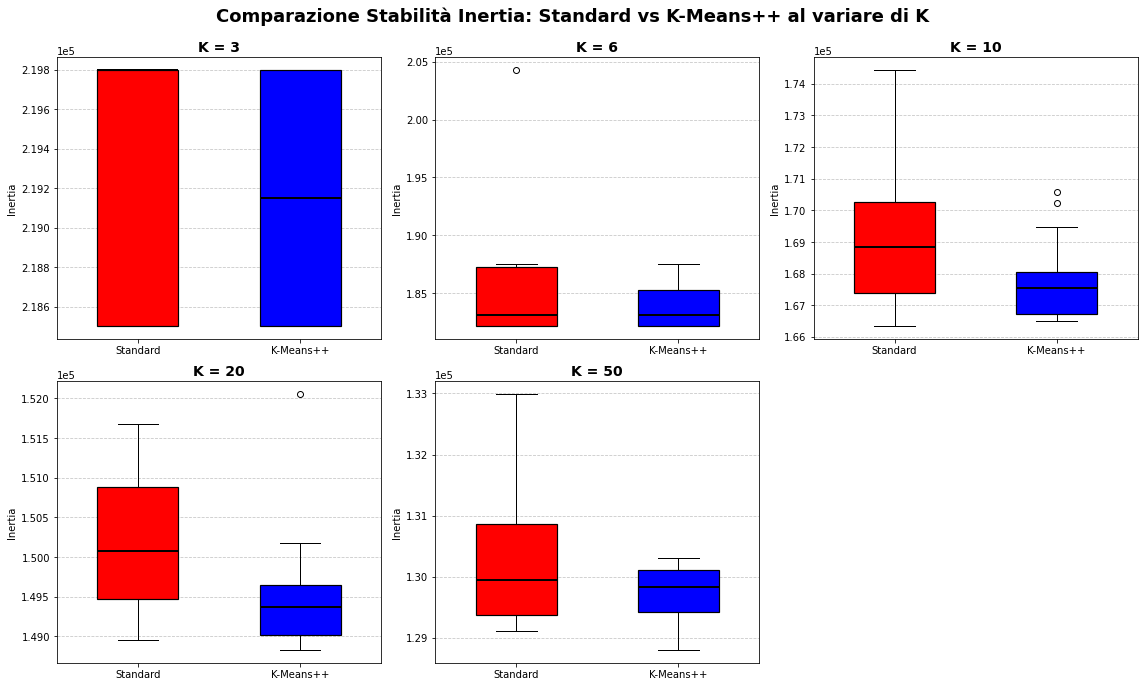

In [19]:
boxplot(k_features,risultati_std,risultati_pplus)
plt.show()

## Risultati su dataset sintentico X

In [20]:
dataset = X
n_tentativi = 20
k_features = [3, 6, 10, 20, 50]
funzione_algoritmo = kmeans_standard
risultati_stdX = {'inertia_media': {}, 'var_inertia': {}, 'tempo_medio': {}, 'distribuzioni': {}, 'insieme_Inertias': {}}

esegui_esperimenti_kmeans(X, k_features, n_tentativi, risultati_stdX , kmeans_standard)

Test: KMEANS_STANDARD
Analisi per k = 3
Tempo di esecuzione kmeans_standard: 0.0111 secondi
1.1695e+09
Tempo di esecuzione kmeans_standard: 0.0058 secondi
1.2565e+09
Tempo di esecuzione kmeans_standard: 0.0056 secondi
1.2643e+09
Tempo di esecuzione kmeans_standard: 0.0064 secondi
1.2396e+09
Tempo di esecuzione kmeans_standard: 0.0058 secondi
1.2323e+09
Tempo di esecuzione kmeans_standard: 0.0083 secondi
1.2374e+09
Tempo di esecuzione kmeans_standard: 0.0084 secondi
1.2239e+09
Tempo di esecuzione kmeans_standard: 0.0055 secondi
1.2401e+09
Tempo di esecuzione kmeans_standard: 0.0081 secondi
1.2784e+09
Tempo di esecuzione kmeans_standard: 0.0109 secondi
1.2156e+09
Tempo di esecuzione kmeans_standard: 0.0086 secondi
1.1987e+09
Tempo di esecuzione kmeans_standard: 0.0133 secondi
1.2495e+09
Tempo di esecuzione kmeans_standard: 0.0081 secondi
1.2135e+09
Tempo di esecuzione kmeans_standard: 0.0111 secondi
1.2015e+09
Tempo di esecuzione kmeans_standard: 0.0113 secondi
1.2156e+09
Tempo di esecuz

In [21]:
dataset = X
n_tentativi = 20
k_features = [3, 6, 10, 20, 50]
funzione_algoritmo = kmeans_plpl
risultati_plplX = {'inertia_media': {}, 'var_inertia': {}, 'tempo_medio': {}, 'distribuzioni': {}, 'insieme_Inertias': {}}

esegui_esperimenti_kmeans(X, k_features, n_tentativi, risultati_plplX, kmeans_plpl)

Test: KMEANS_PLPL
Analisi per k = 3
Tempo di esecuzione kmeans_plpl: 0.0089 secondi
1.2623e+09
Tempo di esecuzione kmeans_plpl: 0.0074 secondi
1.2271e+09
Tempo di esecuzione kmeans_plpl: 0.0144 secondi
1.2420e+09
Tempo di esecuzione kmeans_plpl: 0.0151 secondi
1.1947e+09
Tempo di esecuzione kmeans_plpl: 0.0100 secondi
1.2531e+09
Tempo di esecuzione kmeans_plpl: 0.0125 secondi
1.2375e+09
Tempo di esecuzione kmeans_plpl: 0.0075 secondi
1.2052e+09
Tempo di esecuzione kmeans_plpl: 0.0157 secondi
1.2024e+09
Tempo di esecuzione kmeans_plpl: 0.0098 secondi
1.2256e+09
Tempo di esecuzione kmeans_plpl: 0.0076 secondi
1.2169e+09
Tempo di esecuzione kmeans_plpl: 0.0099 secondi
1.1977e+09
Tempo di esecuzione kmeans_plpl: 0.0100 secondi
1.2136e+09
Tempo di esecuzione kmeans_plpl: 0.0103 secondi
1.2485e+09
Tempo di esecuzione kmeans_plpl: 0.0127 secondi
1.2824e+09
Tempo di esecuzione kmeans_plpl: 0.0103 secondi
1.2461e+09
Tempo di esecuzione kmeans_plpl: 0.0122 secondi
1.2377e+09
Tempo di esecuzione 

In [22]:
risultati(risultati_stdX, risultati_plplX)

- Risultati per K = 3
Standard -> Inertia: 1.2299e+09 | Var: 2.5476e+07 | Tempo: 0.01s
K-Means++-> Inertia: 1.2278e+09 | Var: 2.4697e+07 | Tempo: 0.01s
Miglioramento Inertia:     0.17%
Miglioramento Variabilità: 3.06%
Miglioramento Tempo:       -27.87%

- Risultati per K = 6
Standard -> Inertia: 8.8979e+08 | Var: 5.0268e+07 | Tempo: 0.03s
K-Means++-> Inertia: 8.5295e+08 | Var: 2.5323e+07 | Tempo: 0.02s
Miglioramento Inertia:     4.14%
Miglioramento Variabilità: 49.62%
Miglioramento Tempo:       12.28%

- Risultati per K = 10
Standard -> Inertia: 5.8799e+08 | Var: 6.6525e+07 | Tempo: 0.07s
K-Means++-> Inertia: 5.0262e+08 | Var: 3.9725e+07 | Tempo: 0.05s
Miglioramento Inertia:     14.52%
Miglioramento Variabilità: 40.29%
Miglioramento Tempo:       26.56%

- Risultati per K = 20
Standard -> Inertia: 2.0621e+08 | Var: 7.4775e+07 | Tempo: 0.40s
K-Means++-> Inertia: 1.1996e+05 | Var: 0.0000e+00 | Tempo: 0.16s
Miglioramento Inertia:     99.94%
Miglioramento Variabilità: 100.00%
Miglioramento 

In [23]:
griglia_distribuzioni(risultati_plplX['distribuzioni'], k_features)

In [24]:
griglia_distribuzioni(risultati_stdX['distribuzioni'], k_features)

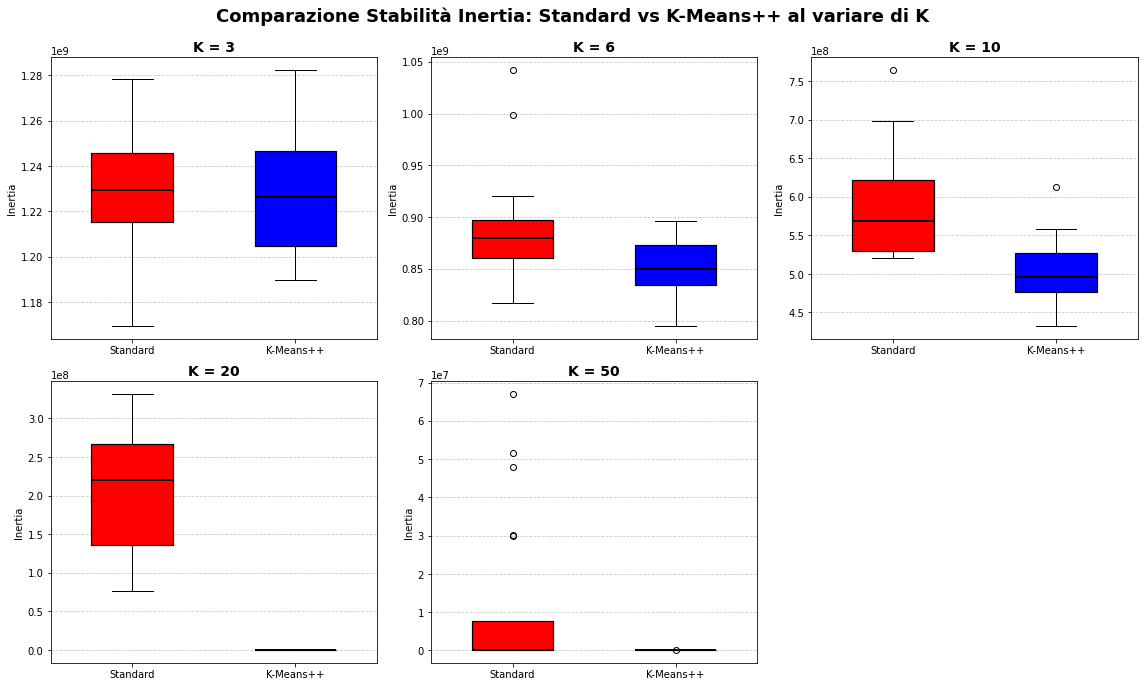

In [25]:
boxplot(k_features,risultati_stdX,risultati_plplX)
plt.show()

In [34]:
import os
import matplotlib.pyplot as plt
import numpy as np

def salva_fotogrammi_distribuzioni(dizionario_distribuzioni, k_features, nome_dataset, nome_cartella, nome_grafico, n_trials=20):
    
    cartella_destinazione = os.path.join("FotoDistribuzioni", nome_dataset, nome_cartella)
    os.makedirs(cartella_destinazione, exist_ok=True)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='white')
    titolo_globale = fig.suptitle(f"{nome_grafico} per tutti i K - Trial 1", fontsize=18, fontweight='bold')
    
    axes = axes.flatten()
    axes[5].axis('off') 
    
    memoria_barre = {}
    memoria_testi = {}
    
    for idx, k in enumerate(k_features):
        ax = axes[idx]
        
        ax.set_facecolor('white')
        
        dati_trial_1 = dizionario_distribuzioni[k][0]
        x = np.arange(k)
        
        max_y = max([max(dist) for dist in dizionario_distribuzioni[k]])
        
        colore_barre = '#66b3ff' if "++" in nome_grafico else '#ff9999'
        
        barre = ax.bar(x, dati_trial_1, color=colore_barre, edgecolor='black')
        ax.set_title(f"Modello con K = {k}", fontsize=14, fontweight='bold')
        ax.set_ylim(0, max_y + (max_y * 0.15))
        
        if k == 50: ax.set_xticks([]) 
        else: ax.set_xticks(x)
            
        etichette = []
        for barra in barre:
            altezza = barra.get_height()
            dimensione_font = 6 if k == 50 else (8 if k == 20 else 10)
            
            testo = ax.text(barra.get_x() + barra.get_width() / 2, altezza + (max_y * 0.02),
                            str(int(altezza)), ha='center', va='bottom', fontsize=dimensione_font)
            etichette.append(testo)
            
        memoria_barre[k] = barre
        memoria_testi[k] = etichette

    plt.tight_layout()
    plt.subplots_adjust(top=0.90) 
    
    for frame in range(n_trials):
        titolo_globale.set_text(f"Evoluzione {nome_grafico} per tutti i K - Trial {frame + 1}")
        
        for k in k_features:
            nuovi_dati = dizionario_distribuzioni[k][frame]
            barre = memoria_barre[k]
            etichette = memoria_testi[k]
            
            for i, (rettangolo, testo) in enumerate(zip(barre, etichette)):
                nuova_altezza = nuovi_dati[i]
                rettangolo.set_height(nuova_altezza)
                testo.set_text(str(int(nuova_altezza)))
                
                y_pos = rettangolo.get_x() + rettangolo.get_width() / 2
                testo.set_position((y_pos, nuova_altezza + (max([max(d) for d in dizionario_distribuzioni[k]]) * 0.02)))
        
        nome_file = os.path.join(cartella_destinazione, f"trial_{frame+1:02d}.png")
        
        plt.savefig(nome_file, dpi=150, bbox_inches='tight', facecolor='white', transparent=False)
        
    plt.close(fig)

In [35]:

salva_fotogrammi_distribuzioni(risultati_plplX['distribuzioni'], k_features, "SinteticoDistr", "plusplus", "K-Means++")
salva_fotogrammi_distribuzioni(risultati_stdX['distribuzioni'], k_features, "SinteticoDistr", "standard", "K-Means Standard")


salva_fotogrammi_distribuzioni(risultati_pplus['distribuzioni'], k_features, "HarDistr", "plusplus", "K-Means++")
salva_fotogrammi_distribuzioni(risultati_std['distribuzioni'], k_features, "HarDistr", "standard", "K-Means Standard")

In [36]:

import os
import matplotlib.pyplot as plt

def salva_boxplot(k_features, risultati_std, risultati_pplus, percorso_salvataggio="boxplot_comparazione.png"):
    cartella = os.path.dirname(percorso_salvataggio)
    if cartella:
        os.makedirs(cartella, exist_ok=True)
        
    figura_pronta = boxplot(k_features, risultati_std, risultati_pplus)
    
    figura_pronta.savefig(percorso_salvataggio, dpi=150, bbox_inches='tight', facecolor='white', transparent=False)
    
    plt.close(figura_pronta)
    

In [37]:

salva_boxplot(k_features, risultati_stdX, risultati_plplX, percorso_salvataggio="FotoDistribuzioni/Boxplot/boxplot_sintetico.png")

salva_boxplot(k_features, risultati_std, risultati_pplus, percorso_salvataggio="FotoDistribuzioni/Boxplot/boxplot_HAR.png")